In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [4]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [5]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

df.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1


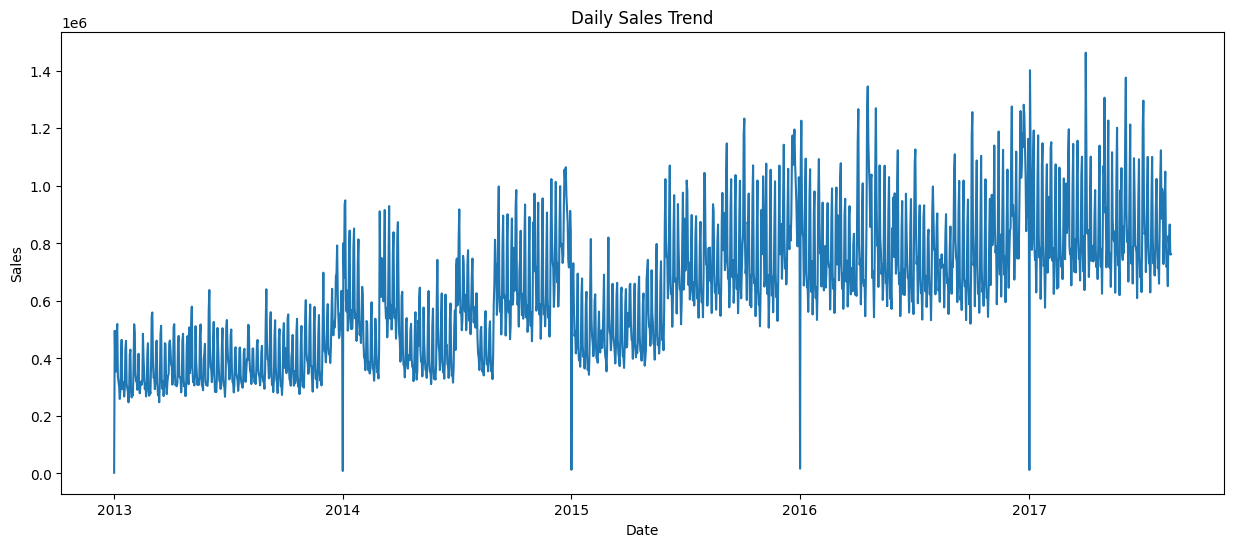

In [7]:
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(15,6))
plt.plot(daily_sales)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

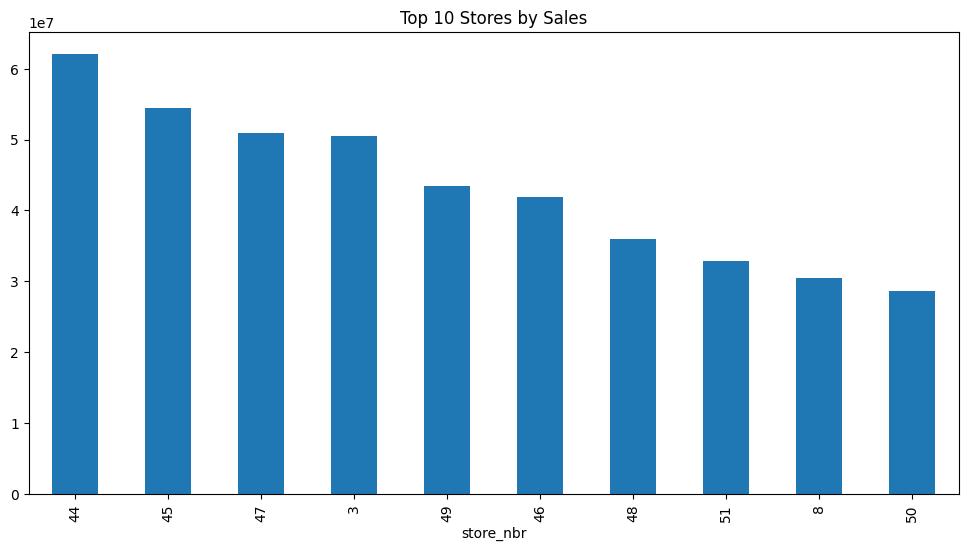

In [8]:
top_stores = df.groupby('store_nbr')['sales'].sum()

plt.figure(figsize=(12,6))
top_stores.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top 10 Stores by Sales')
plt.show()

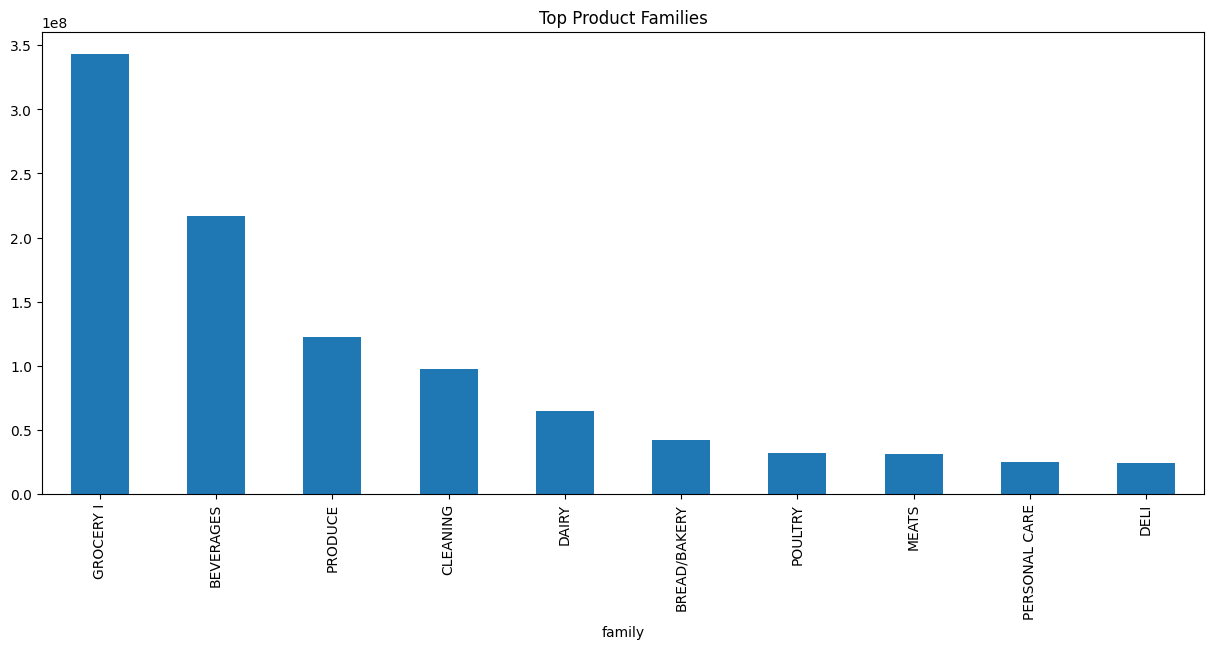

In [9]:
top_products = df.groupby(
    'family'
)['sales'].sum()

plt.figure(figsize=(15,6))

top_products.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top Product Families')
plt.show()

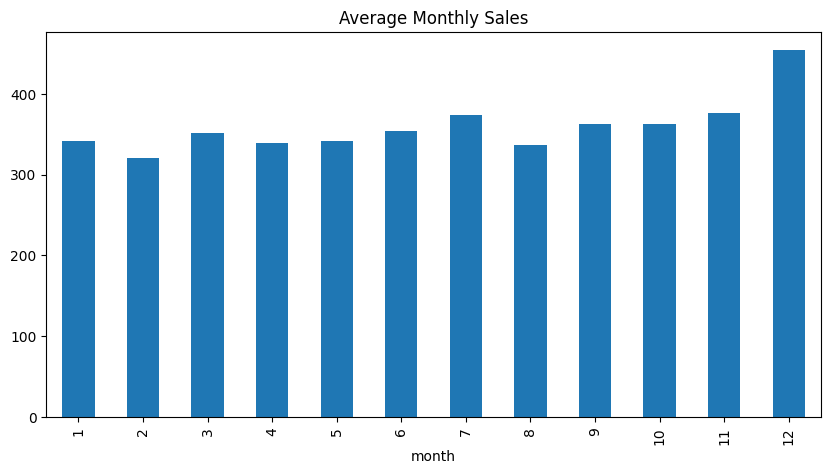

In [10]:
monthly_sales = df.groupby('month')['sales'].mean()

monthly_sales.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Average Monthly Sales")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['family'] = le.fit_transform(df['family'])

<Axes: xlabel='family'>

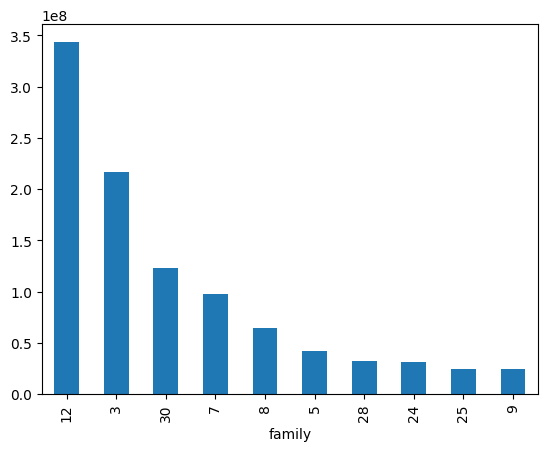

In [12]:
family_sales = df.groupby(
    'family'
)['sales'].sum()

family_sales.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

In [13]:
features = [
    'store_nbr',
    'family',
    'onpromotion',
    'year',
    'month',
    'day',
    'day_of_week'
]

X = df[features]
y = df['sales']

<Axes: xlabel='onpromotion'>

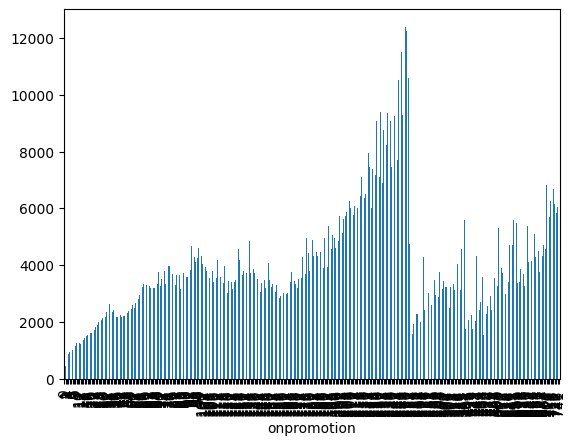

In [14]:
promo_sales = df.groupby(
    'onpromotion'
)['sales'].mean()

promo_sales.plot(
    kind='bar'
)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2400710, 7)
(600178, 7)


In [16]:
df_sample = df.sample(
    n=100000,
    random_state=42
)

print(df_sample.shape)

(100000, 10)


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_sample['family'] = le.fit_transform(
    df_sample['family']
)

In [18]:
features = [
    'store_nbr',
    'family',
    'onpromotion',
    'year',
    'month',
    'day',
    'day_of_week'
]

X = df_sample[features]

y = df_sample['sales']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 7)
(20000, 7)


In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [21]:
pred = model.predict(X_test)

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = mean_squared_error(
    y_test,
    pred
) ** 0.5

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 101.4260123669578
RMSE: 448.8055736700793
R2  : 0.8470173068598725


In [23]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance)

       Feature  Importance
1       family    0.317600
2  onpromotion    0.273186
0    store_nbr    0.247682
6  day_of_week    0.045732
5          day    0.042985
3         year    0.042080
4        month    0.030736


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R²:", lr_r2)

Linear Regression R²: 0.16805563641924604


In [25]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R²:", dt_r2)

Decision Tree R²: 0.7630009891723629


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting R²:", gb_r2)

Gradient Boosting R²: 0.6510627449680677


In [27]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2 Score': [
        lr_r2,
        dt_r2,
        r2,
        gb_r2
    ]
})

comparison = comparison.sort_values(
    by='R2 Score',
    ascending=False
)

print(comparison)

               Model  R2 Score
2      Random Forest  0.847017
1      Decision Tree  0.763001
3  Gradient Boosting  0.651063
0  Linear Regression  0.168056


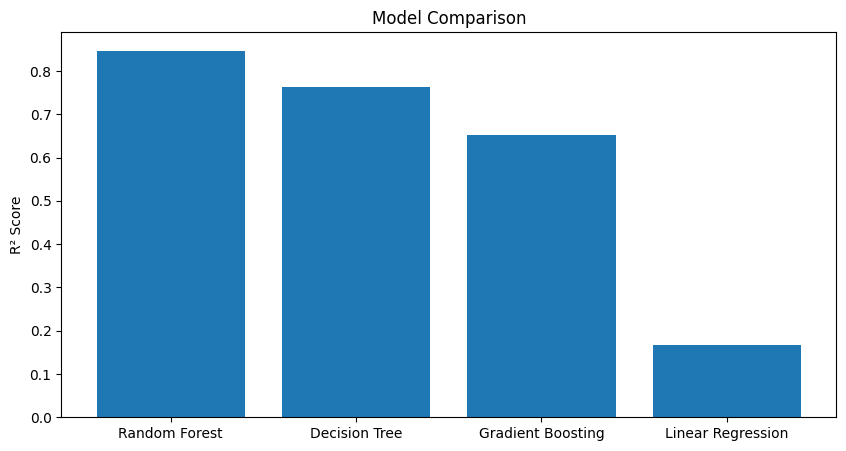

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    comparison['Model'],
    comparison['R2 Score']
)

plt.title("Model Comparison")
plt.ylabel("R² Score")

plt.show()

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


In [30]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score

best_r2 = r2_score(y_test, best_pred)

print("Optimized R²:", best_r2)

Optimized R²: 0.8453431520978928


In [31]:
import joblib

joblib.dump(
    model,
    "../models/sales_forecast_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [32]:
sample_predictions = pd.DataFrame({
    'Actual Sales': y_test[:20],
    'Predicted Sales': pred[:20]
})

sample_predictions

,Actual Sales,Predicted Sales
931936,0.000,0.00000
1051682,733.255,638.84000
703810,2.000,19.32000
167941,0.000,0.00000
396421,290.000,280.40436
433436,0.000,0.92000
2413291,0.000,0.46000
1432213,37.000,68.12000
35560,0.000,11.36000
1170554,0.000,0.00000


In [33]:
sample_predictions.to_csv(
    "../models/sample_predictions.csv",
    index=False
)

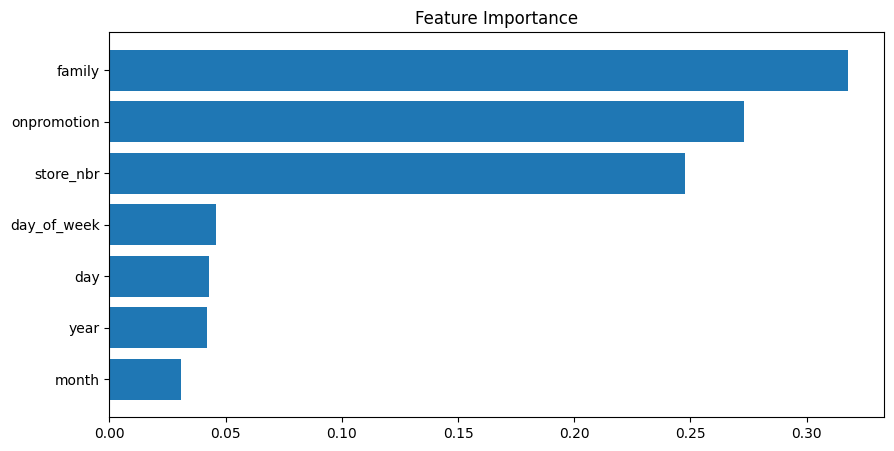

In [34]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title(
    "Feature Importance"
)

plt.show()

In [35]:
plt.savefig(
    "../screenshots/feature_importance.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

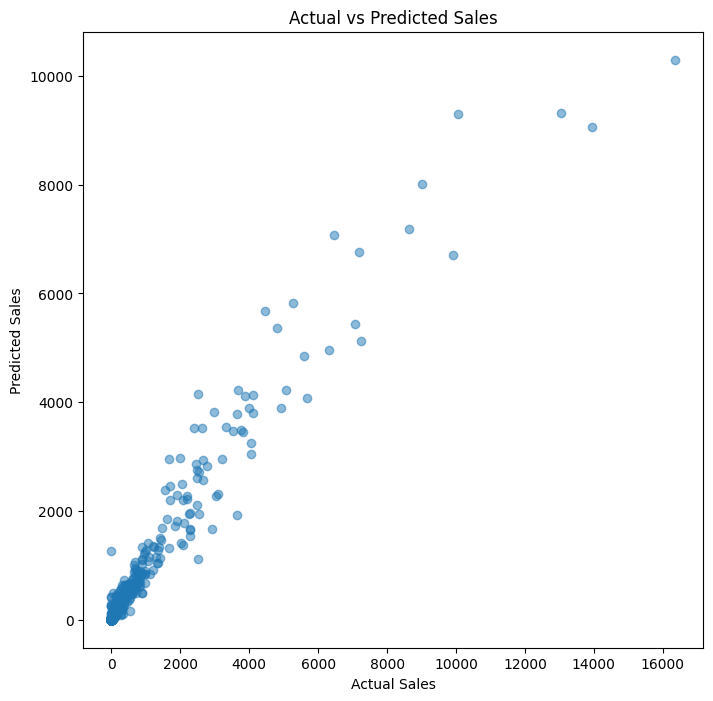

In [36]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test[:1000],
    pred[:1000],
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

In [37]:
import os

print(os.getcwd())
print(os.path.abspath("../models/sales_forecast_model.pkl"))

c:\Retail-Sales-Forecasting-and-Demand-Prediction\notebooks
c:\Retail-Sales-Forecasting-and-Demand-Prediction\models\sales_forecast_model.pkl


In [38]:
import sklearn
print(sklearn.__version__)

1.4.1.post1


In [39]:
joblib.dump(
    model,
    "../models/sales_forecast_model.pkl"
)

['../models/sales_forecast_model.pkl']

In [40]:
loaded_model = joblib.load(
    "../models/sales_forecast_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [41]:
import joblib

joblib.dump(
    le,
    "../models/label_encoder.pkl"
)

print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully
